# Exercise 10.1: Stochastic simulation of gating

In this exercise, we will simulate the random, stochastic flickering of single ion channels and demonstrate how they sum together to create smooth macroscopic currents.

We will use a simple three-state Markov model:
Closed (C) $\rightleftharpoons$ Open (O) $\rightleftharpoons$ Inactivated (I)

First, we will define a transition matrix for this system and solve it deterministically using `solve_ivp`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Define the matrix for the three state Markov Model (C, O, I)
def transition_matrix(k_co, k_oc, k_oi, k_io):
    C, O, I = 0, 1, 2
    n = 3
    A = np.zeros((n, n))

    # Add the forward and backward rates between states
    A[O, C] = k_co  # Rate from C to O
    A[C, O] = k_oc  # Rate from O to C
    A[I, O] = k_oi  # Rate from O to I
    A[O, I] = k_io  # Rate from I to O

    # Ensure conservation of mass (columns must sum to 0)
    for j in range(n):
        A[j, j] = -np.sum(A[:, j])

    return A


# Set transition rates and generate the matrix
k_co, k_oc, k_oi, k_io = 5.0, 10.0, 1.0, 0.0
A = transition_matrix(k_co, k_oc, k_oi, k_io)
print("Transition Matrix A:\n", A)

Transition Matrix A:
 [[ -5.  10.   0.]
 [  5. -11.   0.]
 [  0.   1.  -0.]]


## Exercise 10.1a: Deterministic macroscopic solution

Now we define our ODE system $\frac{\mathrm{d}Y}{\mathrm{d}t} = A \cdot Y$ and solve it. We assume 100% of the channels start in the Closed state.


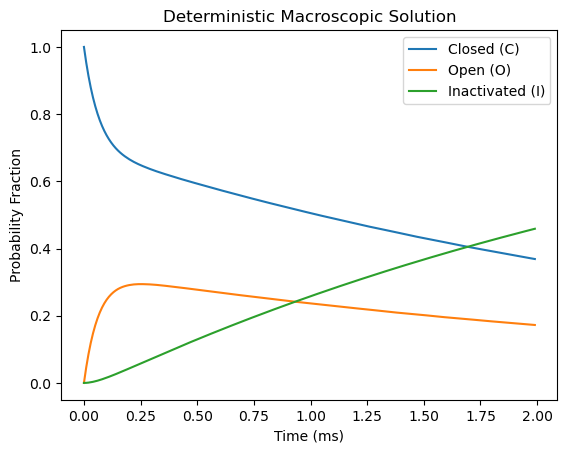

In [ ]:
def ode_system(t, y, A):
    return np.dot(A, y)


Y0 = [1.0, 0.0, 0.0]  # Start entirely in Closed state
t_span = (0, 2.0)
t_eval = np.arange(0, 2.0, 0.01)

# Solve the deterministic ODE
sol = solve_ivp(ode_system, t_span, Y0, args=(A,), t_eval=t_eval)

plt.plot(sol.t, sol.y[0], label="Closed (C)")
plt.plot(sol.t, sol.y[1], label="Open (O)")
plt.plot(sol.t, sol.y[2], label="Inactivated (I)")
plt.legend()
plt.xlabel("Time (ms)")
plt.ylabel("Probability Fraction")
plt.title("Deterministic Macroscopic Solution")
plt.show()

## Exercise 10.1b: Single-channel stochastic simulation

Below is the code for a stochastic simulation. Given a channel's current state and a small time step, we use random numbers to determine if the channel transitions to a new state based on the exact same rate matrix `A`.

Try running this cell several times! You will notice that the channel flickers open and closed randomly, but eventually gets trapped in the Inactivated state.


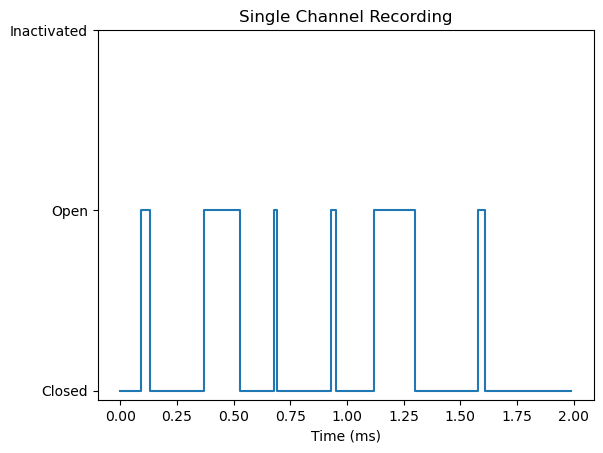

In [ ]:
def advance_stochastic(state, A, dt):
    # Calculate probabilities of leaving the current state
    P = A[:, state] * dt
    P[state] = 0  # Remove the self-transition diagonal

    # Cumulative probability for random selection
    CP = np.cumsum(P)
    random_number = np.random.rand()

    for i in range(len(CP)):
        if random_number < CP[i]:
            return i  # Transitioned to new state

    return state  # Stayed in current state


# Simulate a single channel
dt = 0.01
t = sol.t
s = np.zeros(len(t), dtype=int)
s[0] = 0  # Start Closed

for i in range(len(t) - 1):
    s[i + 1] = advance_stochastic(s[i], A, dt)

plt.step(t, s, where="post")
plt.yticks([0, 1, 2], ["Closed", "Open", "Inactivated"])
plt.xlabel("Time (ms)")
plt.title("Single Channel Recording")
plt.show()

_Question:_ The Inactivated state seems to be an "absorbing" state (once it enters, it never leaves). Looking at the transition rates we set (`k_io = 0.0`), why does this happen?


## Exercise 10.1c: Bridging the micro and macro

Now, let's simulate $N = 1000$ individual stochastic channels simultaneously, and take the average across the entire population. We will plot this stochastic population average alongside the perfectly smooth deterministic solution we found in 10.1a.


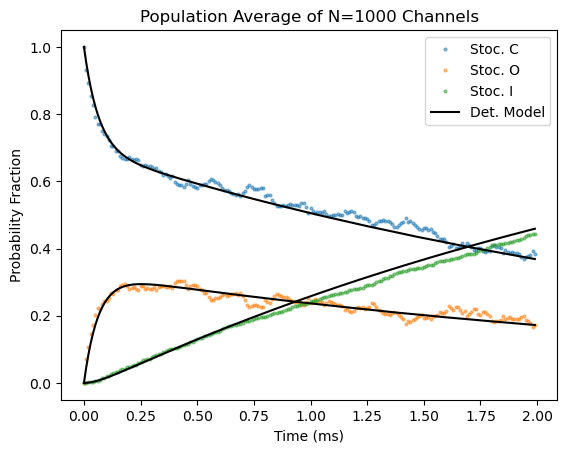

In [ ]:
N = 1000  # Number of simulated channels
S = np.zeros((len(t), N), dtype=int)

# Simulate N independent channels
for n in range(N):
    S[0, n] = 0
    for i in range(len(t) - 1):
        S[i + 1, n] = advance_stochastic(S[i, n], A, dt)

# Calculate the fraction of channels in each state at every time step
p_C = np.mean(S == 0, axis=1)
p_O = np.mean(S == 1, axis=1)
p_I = np.mean(S == 2, axis=1)

# Plot Stochastic Averages (scatter points)
plt.plot(t, p_C, "o", color="C0", markersize=2, alpha=0.5, label="Stoc. C")
plt.plot(t, p_O, "o", color="C1", markersize=2, alpha=0.5, label="Stoc. O")
plt.plot(t, p_I, "o", color="C2", markersize=2, alpha=0.5, label="Stoc. I")

# Overlay Deterministic Solution (solid lines)
plt.plot(sol.t, sol.y[0], color="black", linewidth=1.5, label="Det. Model")
plt.plot(sol.t, sol.y[1], color="black", linewidth=1.5)
plt.plot(sol.t, sol.y[2], color="black", linewidth=1.5)

plt.legend()
plt.xlabel("Time (ms)")
plt.ylabel("Probability Fraction")
plt.title(f"Population Average of N={N} Channels")
plt.show()

As you can see, when we average enough stochastic channels together, the random noise perfectly cancels out, leaving us with the exact macroscopic differential equations we use to model whole cells!

Try changing $N$ to 10 or 50 in the code above to see how "noisy" the macroscopic current becomes when a cell has too few channels.
